<a href="https://colab.research.google.com/github/wizzy-7/Pytorch101/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class Model(nn.Module):
  # Input layer; in_features = 4; features of the flower
  # hidden layers 1 & 2; h1 = n, h2 = n; number of neurons
  # Output layer; out_features = 3; 3 classes of flower
  def __init__(self, in_features=4, h1=29, h2=30, h3=30, out_features=3):
    super().__init__() # Instanciate nn.Module
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.fc3 = nn.Linear(h2, h3)
    self.out = nn.Linear(h3, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.out(x)

    return x


In [ ]:
torch.manual_seed(74) # Pick a random seed for randomization
model = Model()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
data = pd.read_csv(url)
data.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [ ]:
# Change last column from strings to integers
data.variety = data.variety.replace("Setosa", 0.0)
data.variety = data.variety.replace("Versicolor", 1.0)
data.variety = data.variety.replace("Virginica", 2.0)

/tmp/ipykernel_1006/2993825429.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.variety = data.variety.replace("Virginica", 2.0)


In [ ]:
X = data.drop("variety", axis=1)
y = data.variety
X = X.values
y = y.values

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

In [ ]:
# Converting X and y to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [ ]:
# Set criterion to measure error
criterion = nn.CrossEntropyLoss()
# Using Adam optimizer. lr = learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# Training the model
# Epochs? 1 run through the date set in the nn
epochs = 100
losses = []

for i in range(epochs):
  # Make a prediction
  y_pred = model.forward(X_train)

  # Measure the loss
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  if i % 10 == 0:
    print(f"Epoch: {i}, Loss: {loss}")

  # Back propagation
  optimizer.zero_grad() # clear gradients at the start of every epoch
  loss.backward() # uses gradients to update weights in the direction that minimizes losses
  optimizer.step()



Epoch: 0, Loss: 1.0994271039962769
Epoch: 10, Loss: 0.691926896572113
Epoch: 20, Loss: 0.3233569264411926
Epoch: 30, Loss: 0.08919192105531693
Epoch: 40, Loss: 0.057711683213710785
Epoch: 50, Loss: 0.05587984248995781
Epoch: 60, Loss: 0.05633681267499924
Epoch: 70, Loss: 0.0547366589307785
Epoch: 80, Loss: 0.053828656673431396
Epoch: 90, Loss: 0.052851736545562744


Text(0.5, 0, 'Epochs')

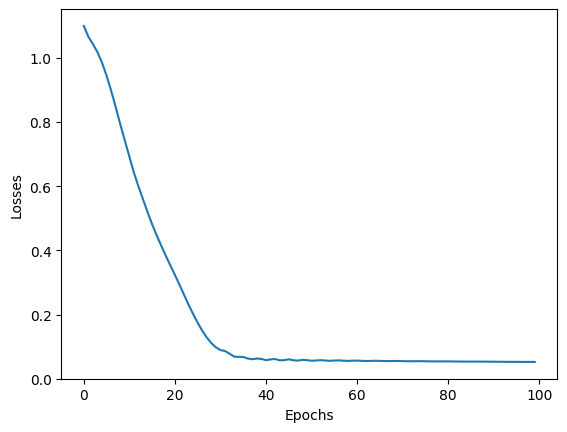

In [ ]:
plt.plot(range(epochs), losses)
plt.ylabel("Losses")
plt.xlabel("Epochs")

In [ ]:
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)
loss

tensor(0.0283)

In [ ]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    # Will tell us what flower class the nn thinks it is
    print(f"{i + 1}.)  {str(y_val)} \t {y_test[i]} \t{y_val.argmax().item()}")

    if y_val.argmax().item() == y_test[i]: # check if the class predicted is the same as that fo the true class
      correct += 1

print(f"\nCorrect = {correct}/{len(y_test)}")

1.)  tensor([-7.3167,  7.3577,  1.1531]) 	 1 	1
2.)  tensor([ 12.7566,   1.3409, -14.7382]) 	 0 	0
3.)  tensor([ 11.6908,   1.6230, -13.9007]) 	 0 	0
4.)  tensor([-8.0133,  7.9237,  1.3849]) 	 1 	1
5.)  tensor([-14.1011,   6.1671,  10.1199]) 	 2 	2
6.)  tensor([-16.1407,   7.9568,  10.6618]) 	 2 	2
7.)  tensor([ 10.9981,   1.8714, -13.4266]) 	 0 	0
8.)  tensor([ 11.8032,   1.4616, -13.8524]) 	 0 	0
9.)  tensor([-7.0028,  7.8743,  0.2766]) 	 1 	1
10.)  tensor([ 12.5438,   1.5096, -14.6847]) 	 0 	0
11.)  tensor([-8.1473,  8.2855,  1.1753]) 	 1 	1
12.)  tensor([-16.4878,   5.5514,  13.4858]) 	 2 	2
13.)  tensor([-3.8864,  6.7265, -2.2626]) 	 1 	1
14.)  tensor([-3.8181,  7.7708, -3.4978]) 	 1 	1
15.)  tensor([-14.3414,   6.2505,  10.3215]) 	 2 	2
16.)  tensor([-16.0767,   4.6797,  13.8894]) 	 2 	2
17.)  tensor([-8.2051,  7.0128,  2.5191]) 	 1 	1
18.)  tensor([-12.5912,   6.3769,   8.1889]) 	 2 	2
19.)  tensor([-4.2919,  7.4891, -2.5871]) 	 1 	1
20.)  tensor([ 13.3229,   1.5490, -15.5494]) 

In [ ]:
#  Save the model
torch.save(model.state_dict(), "my_first_ml_model.pt")

In [ ]:
new_model = Model()
new_model.load_state_dict(torch.load("my_first_ml_model.pt"))

<All keys matched successfully>

In [ ]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=29, bias=True)
  (fc2): Linear(in_features=29, out_features=30, bias=True)
  (fc3): Linear(in_features=30, out_features=30, bias=True)
  (out): Linear(in_features=30, out_features=3, bias=True)
)